# Horizontal scale of Utqiagvik cloud decks from Taylor's frozen-turbulence hypothesis

**Site:** DOE ARM North Slope of Alaska (NSA) Central Facility, Utqiagvik (Barrow), 71.323 N, 156.609 W.
**Season:** 1 October 2025 - 31 March 2026 (one cold season).

### The idea

Taylor's (1938) frozen-turbulence hypothesis assumes the field is advected past
a fixed sensor faster than it evolves. Under that assumption a duration
measured at the sensor maps directly onto a distance along the wind:

$$L_\mathrm{horizontal} = U_\mathrm{advection}\,\Delta t$$

A zenith-pointing instrument at Utqiagvik that sees cloud continuously for
$\Delta t$ is therefore sampling a chord of length $L$ through an advecting
cloud deck. This notebook builds the wind-speed side of that conversion: the
distribution of $U$ over one cold season, and the resulting $L(\Delta t)$ for
$\Delta t$ from 1 minute to 1 hour.

### Three caveats that belong with every number below

1. **$L$ is a chord, not a diameter.** The site samples one transect through
   the cloud, generally off-centre, so $L$ underestimates the cloud's largest
   horizontal dimension.
2. **Wind speed is used as a scalar.** The advection speed that matters is the
   component perpendicular to the cloud edge being crossed; using the full
   speed makes $L$ an overestimate of the chord for a given $\Delta t$. This
   pushes the opposite way from caveat 1.
3. **The hypothesis degrades as $\Delta t$ grows.** It requires the cloud's own
   evolution timescale to be long compared with $\Delta t$. Individual Arctic
   stratocumulus cells turn over in roughly 10-20 minutes, so the 1-hour end of
   this plot should be read as the scale of the *deck* -- a persistent,
   advecting field -- not of any single cell.

### Where the wind comes from

`nsatwrC1.b1`, the ARM **Forty Meter Tower** product: 1-minute averages of wind
speed and direction at **2, 10, 20 and 40 m AGL**. The 40-m level is the top of
the tower and the best available *in situ* surrogate for the wind that advects a
boundary-layer cloud deck; the lower levels are carried through so the surface
shear is visible and so the sensitivity of $L$ to the choice of level is
explicit rather than assumed.

Download it with:

```bash
python scripts/download_nsa_wind_data.py --season 2025
```

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, MultipleLocator, NullFormatter

# Make the repo importable when the notebook is opened from its own directory.
REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from arm_nsa import config
from arm_nsa.surface import read_met, read_tower_winds, tower_level

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12.5,
        "axes.linewidth": 1.1,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.frameon": True,
        "legend.framealpha": 0.92,
        "legend.edgecolor": "0.75",
    }
)

# One colour per tower level, light -> dark with height, so the 40-m level
# (the one the cloud-scale estimate uses) reads as the primary series.
LEVEL_COLORS_M = {2.0: "#BBD3E8", 10.0: "#7FA8CE", 20.0: "#3D74A8", 40.0: "#12395E"}

## 1. Load one cold season of tower winds

In [2]:
SEASON_START = "2025-10-01"
SEASON_END = "2026-03-31"

# apply_qc_flags=True NaNs out samples whose ARM QC bits carry a "Bad"
# assessment (missing value, outside valid_min/valid_max, failed delta check).
twr = read_tower_winds(SEASON_START, SEASON_END, apply_qc_flags=True)
twr

<xarray.Dataset> Size: 23MB
Dimensions:         (time: 262080, height: 4)
Coordinates:
  * time            (time) datetime64[ns] 2MB 2025-10-01 ... 2026-03-31T23:59:00
  * height          (height) int32 16B 2 10 20 40
Data variables:
    wspd_arith_m_s  (time, height) float32 4MB 4.423 5.372 5.54 ... 5.1 5.072
    wspd_vec_m_s    (time, height) float32 4MB 4.42 5.37 5.539 ... 5.095 5.068
    wdir_deg        (time, height) float32 4MB 53.55 54.75 58.8 ... 130.6 125.5
    temp_c          (time, height) float32 4MB -3.0 -2.787 ... -15.15 -16.0
    rh_pct          (time, height) float32 4MB 89.5 88.7 88.6 ... 78.73 82.7

In [3]:
# Coverage: how much of the season actually has usable wind at each level?
n_days = (pd.Timestamp(SEASON_END) - pd.Timestamp(SEASON_START)).days + 1
n_expected_1min = n_days * 24 * 60

print(f"season          : {SEASON_START} .. {SEASON_END}  ({n_days} days)")
print(f"records present : {twr.sizes['time']:,} of {n_expected_1min:,} possible "
      f"1-min slots ({100 * twr.sizes['time'] / n_expected_1min:.1f}%)")
print(f"first / last    : {str(twr.time.values[0])[:19]} / {str(twr.time.values[-1])[:19]}")
print(f"tower heights   : {[float(h) for h in twr.height.values]} m AGL")
print()
for h in twr.height.values:
    finite = np.isfinite(tower_level(twr, float(h))["wspd_vec_m_s"].values).sum()
    print(f"  {float(h):5.1f} m : {finite:,} finite wind samples "
          f"({100 * finite / twr.sizes['time']:.1f}% of records)")

season          : 2025-10-01 .. 2026-03-31  (182 days)
records present : 262,080 of 262,080 possible 1-min slots (100.0%)
first / last    : 2025-10-01T00:00:00 / 2026-03-31T23:59:00
tower heights   : [2.0, 10.0, 20.0, 40.0] m AGL

    2.0 m : 261,542 finite wind samples (99.8% of records)
   10.0 m : 262,039 finite wind samples (100.0% of records)
   20.0 m : 262,008 finite wind samples (100.0% of records)
   40.0 m : 261,582 finite wind samples (99.8% of records)


### Screening: ARM's QC is not enough at the 2-m level

`apply_qc_flags=True` above applies ARM's embedded QC bits, one of which is a
`valid_max` test. For tower wind speed that `valid_max` is **100 m/s**, which is
a plausibility check on the data logger rather than on the atmosphere, and it
lets obvious instrument faults through. The screen below catches them.

In [4]:
# Anything above this is a failed anemometer, not weather (config.py carries
# the reasoning). Screened samples are reported, not silently dropped.
MAX_WSPD_M_S = config.MAX_PLAUSIBLE_WSPD_M_S

print(f"Samples exceeding {MAX_WSPD_M_S:.0f} m/s after ARM QC, per level:")
for h in twr.height.values:
    u_m_s = twr["wspd_vec_m_s"].sel(height=h).values
    finite = np.isfinite(u_m_s)
    n_bad = int((finite & (u_m_s > MAX_WSPD_M_S)).sum())
    print(f"  {float(h):5.1f} m : {n_bad:4d} of {finite.sum():,} "
          f"({100 * n_bad / finite.sum():.4f}%)   max = {u_m_s[finite].max():6.1f} m/s")

# Show one flagged minute in full, so the fault is visible rather than asserted:
# a real 99 m/s wind at 2 m cannot coexist with 12 m/s at 40 m.
u2_m_s = twr["wspd_vec_m_s"].sel(height=2.0).values
worst = int(np.nanargmax(u2_m_s))
print(f"\nWorst 2-m sample, {str(twr.time.values[worst])[:19]} UTC:")
for h in twr.height.values:
    print(f"  {float(h):5.1f} m : {float(twr['wspd_vec_m_s'].sel(height=h).values[worst]):6.2f} m/s")

Samples exceeding 30 m/s after ARM QC, per level:
    2.0 m :   43 of 261,542 (0.0164%)   max =   99.0 m/s
   10.0 m :    0 of 262,039 (0.0000%)   max =   21.2 m/s
   20.0 m :    0 of 262,008 (0.0000%)   max =   21.7 m/s
   40.0 m :    0 of 261,582 (0.0000%)   max =   23.4 m/s

Worst 2-m sample, 2025-12-12T22:56:00 UTC:
    2.0 m :  99.00 m/s
   10.0 m :  10.59 m/s
   20.0 m :  11.03 m/s
   40.0 m :  11.84 m/s


In [5]:
# Apply the screen to every wind field, at every level.
for var in ("wspd_arith_m_s", "wspd_vec_m_s"):
    twr[var] = twr[var].where(twr[var] <= MAX_WSPD_M_S)

print(f"Screened. New per-level maxima [m/s]:")
for h in twr.height.values:
    u_m_s = twr["wspd_vec_m_s"].sel(height=h).values
    print(f"  {float(h):5.1f} m : {np.nanmax(u_m_s):6.2f}")

Screened. New per-level maxima [m/s]:
    2.0 m :  29.54
   10.0 m :  21.17
   20.0 m :  21.69
   40.0 m :  23.38


### Cross-check: the 10-m tower level against the MET station

`nsametC1.b1` reports a single wind level at 10 m (`wind_measurement_height: 10m`
in its file header) and is ingested from the same `METData` collection as the
tower stream. It is therefore *not* an independent measurement -- the check
below should show the two are identical, and any disagreement would mean one of
the two ingests is being read wrong.

In [6]:
met = read_met(SEASON_START, SEASON_END, apply_qc_flags=True)

# Align on the common 1-min timestamps before differencing.
twr_10m = tower_level(twr, 10.0)["wspd_vec_m_s"]
met_wspd = met["wspd_m_s"]  # config maps this to wspd_vec_mean, the same flavour
common = np.intersect1d(twr_10m.time.values, met_wspd.time.values)
a_m_s = twr_10m.sel(time=common).values
b_m_s = met_wspd.sel(time=common).values
both = np.isfinite(a_m_s) & np.isfinite(b_m_s)

diff_m_s = a_m_s[both] - b_m_s[both]
print(f"matched samples          : {both.sum():,}")
print(f"max |tower_10m - met|    : {np.abs(diff_m_s).max():.4f} m/s")
print(f"RMS difference           : {np.sqrt((diff_m_s ** 2).mean()):.4f} m/s")
print()
print("Expected: both ~0. A nonzero result would mean the two ingests are NOT")
print("the same measurement after all, and the 10-m level needs re-checking.")

matched samples          : 262,039
max |tower_10m - met|    : 0.0000 m/s
RMS difference           : 0.0000 m/s

Expected: both ~0. A nonzero result would mean the two ingests are NOT
the same measurement after all, and the 10-m level needs re-checking.


## 2. The wind-speed distribution

Two wind-speed flavours are in the file. `wspd_arith_m_s` is the mean *speed*
over the minute; `wspd_vec_m_s` is the magnitude of the mean *velocity*, i.e.
net displacement per unit time. Taylor's hypothesis converts a duration into a
displacement, so the vector mean is the correct choice; the arithmetic mean is
tabulated alongside it to show how little the choice matters here.

In [7]:
WIND_VAR = "wspd_vec_m_s"  # the displacement-per-unit-time flavour
HEIGHTS_M = [float(h) for h in twr.height.values]


def level_speeds_m_s(ds: xr.Dataset, height_m: float, var: str = WIND_VAR) -> np.ndarray:
    # Finite 1-min wind speeds [m/s] at one tower level, NaNs dropped.
    u_m_s = tower_level(ds, height_m)[var].values
    return u_m_s[np.isfinite(u_m_s)]


rows = []
for var in ("wspd_vec_m_s", "wspd_arith_m_s"):
    for h_m in HEIGHTS_M:
        u_m_s = level_speeds_m_s(twr, h_m, var)
        q25_m_s, q50_m_s, q75_m_s = np.percentile(u_m_s, [25, 50, 75])
        rows.append(
            {
                "wind_variable": var,
                "height_m": h_m,
                "n_samples": u_m_s.size,
                "q25_m_s": q25_m_s,
                "median_m_s": q50_m_s,
                "q75_m_s": q75_m_s,
                "iqr_m_s": q75_m_s - q25_m_s,
                "mean_m_s": u_m_s.mean(),
                "p95_m_s": np.percentile(u_m_s, 95),
                "max_m_s": u_m_s.max(),
            }
        )

wind_stats = pd.DataFrame(rows).set_index(["wind_variable", "height_m"])
wind_stats.round(2)

n_samples  q25_m_s  median_m_s  q75_m_s  iqr_m_s  \
wind_variable  height_m                                                     
wspd_vec_m_s   2.0          261499     2.61        4.19     6.29     3.68   
               10.0         262039     3.64        5.31     7.61     3.97   
               20.0         262008     4.12        6.04     8.27     4.15   
               40.0         261582     4.46        6.72     9.19     4.73   
wspd_arith_m_s 2.0          261481     2.61        4.20     6.30     3.69   
               10.0         262039     3.64        5.32     7.62     3.98   
               20.0         262008     4.12        6.04     8.27     4.15   
               40.0         261582     4.46        6.72     9.20     4.74   

                         mean_m_s  p95_m_s    max_m_s  
wind_variable  height_m                                
wspd_vec_m_s   2.0           4.58     9.13  29.540001  
               10.0          5.75    10.96  21.170000  
               20.0          6.33    11.74  21.690001  
               40.0          6.96    12.82  23.379999  
wspd_arith_m_s 2.0           4.59     9.15  29.330000  
               10.0          5.75    10.98  21.190001  
               20.0          6.34    11.75  21.709999  
               40.0          6.97    12.83  23.389999

In [8]:
# The three numbers the cloud-scale estimate is built on, at the top of the tower.
TOP_HEIGHT_M = 40.0
u_top_m_s = level_speeds_m_s(twr, TOP_HEIGHT_M)
U_Q25_M_S, U_MEDIAN_M_S, U_Q75_M_S = np.percentile(u_top_m_s, [25, 50, 75])

print(f"{TOP_HEIGHT_M:.0f}-m wind speed, {SEASON_START} .. {SEASON_END}")
print(f"  25th percentile : {U_Q25_M_S:5.2f} m/s")
print(f"  median          : {U_MEDIAN_M_S:5.2f} m/s")
print(f"  75th percentile : {U_Q75_M_S:5.2f} m/s")
print(f"  IQR width       : {U_Q75_M_S - U_Q25_M_S:5.2f} m/s")

40-m wind speed, 2025-10-01 .. 2026-03-31
  25th percentile :  4.46 m/s
  median          :  6.72 m/s
  75th percentile :  9.19 m/s
  IQR width       :  4.73 m/s


## 3. Taylor conversion: duration to horizontal scale

In [9]:
def taylor_length_km(u_m_s, duration_s):
    # Horizontal chord length [km] from Taylor's frozen-turbulence hypothesis:
    # L = U * dt, with U in m/s and dt in seconds. Broadcasting follows numpy
    # rules, so a scalar U with an array of durations gives one curve.
    return np.asarray(u_m_s) * np.asarray(duration_s) / 1000.0


# Durations from 1 minute to 1 hour, log-spaced so the short end is resolved.
DURATION_MIN = np.logspace(
    np.log10(config.CLOUD_DURATION_MIN_S / 60.0),
    np.log10(config.CLOUD_DURATION_MAX_S / 60.0),
    200,
)
DURATION_S = DURATION_MIN * 60.0

L_median_km = taylor_length_km(U_MEDIAN_M_S, DURATION_S)
L_q25_km = taylor_length_km(U_Q25_M_S, DURATION_S)
L_q75_km = taylor_length_km(U_Q75_M_S, DURATION_S)

# A readable table at round durations.
TABLE_DURATIONS_MIN = np.array([1, 2, 5, 10, 15, 20, 30, 45, 60], dtype=float)
scale_table = pd.DataFrame(
    {
        "duration_min": TABLE_DURATIONS_MIN,
        "L_q25_km": taylor_length_km(U_Q25_M_S, TABLE_DURATIONS_MIN * 60.0),
        "L_median_km": taylor_length_km(U_MEDIAN_M_S, TABLE_DURATIONS_MIN * 60.0),
        "L_q75_km": taylor_length_km(U_Q75_M_S, TABLE_DURATIONS_MIN * 60.0),
    }
).set_index("duration_min")

print(f"Horizontal cloud scale at U({TOP_HEIGHT_M:.0f} m) = "
      f"{U_MEDIAN_M_S:.2f} m/s (median), IQR {U_Q25_M_S:.2f}-{U_Q75_M_S:.2f} m/s")
scale_table.round(2)

Horizontal cloud scale at U(40 m) = 6.72 m/s (median), IQR 4.46-9.19 m/s


,L_q25_km,L_median_km,L_q75_km
duration_min,,,
1.0,0.27,0.40,0.55
2.0,0.53,0.81,1.10
5.0,1.34,2.02,2.76
10.0,2.67,4.03,5.51
15.0,4.01,6.05,8.27
20.0,5.35,8.06,11.03
30.0,8.02,12.09,16.54
45.0,12.04,18.14,24.81
60.0,16.05,24.19,33.08


## 4. Figure

figure saved: figures/taylor_cloud_scale_nsa_2025-10-01_2026-03-31.png


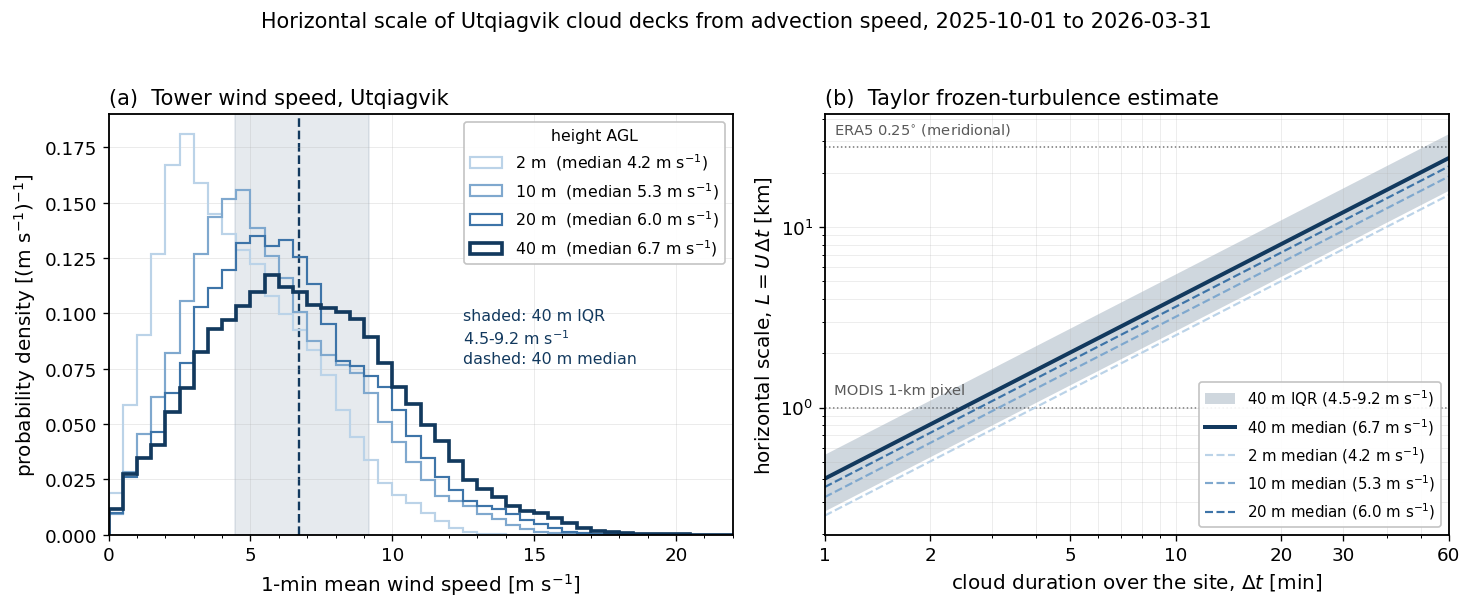

In [10]:
fig, (ax_dist, ax_scale) = plt.subplots(1, 2, figsize=(12.4, 4.9))

# ---- (a) wind-speed distributions at all four tower levels ----------------
bins_m_s = np.arange(0, 26.5, 0.5)
for h_m in HEIGHTS_M:
    u_m_s = level_speeds_m_s(twr, h_m)
    ax_dist.hist(
        u_m_s,
        bins=bins_m_s,
        density=True,
        histtype="step",
        lw=2.2 if h_m == TOP_HEIGHT_M else 1.3,
        color=LEVEL_COLORS_M[h_m],
        label=f"{h_m:.0f} m  (median {np.median(u_m_s):.1f} m s$^{{-1}}$)",
    )

# Shade the 40-m IQR: this is the band that becomes the wedge in panel (b).
ax_dist.axvspan(U_Q25_M_S, U_Q75_M_S, color=LEVEL_COLORS_M[40.0], alpha=0.10, zorder=0)
ax_dist.axvline(U_MEDIAN_M_S, color=LEVEL_COLORS_M[40.0], ls="--", lw=1.4, zorder=1)
y_top = ax_dist.get_ylim()[1]
ax_dist.text(
    U_Q75_M_S + 3.3, y_top * 0.47,
    f"shaded: 40 m IQR\n{U_Q25_M_S:.1f}-{U_Q75_M_S:.1f} m s$^{{-1}}$\n"
    f"dashed: 40 m median",
    fontsize=9.5, color=LEVEL_COLORS_M[40.0], va="center", linespacing=1.35,
)

ax_dist.set_xlim(0, 22)
ax_dist.set_xlabel("1-min mean wind speed [m s$^{-1}$]")
ax_dist.set_ylabel("probability density [(m s$^{-1}$)$^{-1}$]")
ax_dist.set_title("(a)  Tower wind speed, Utqiagvik", loc="left")
ax_dist.xaxis.set_major_locator(MultipleLocator(5))
ax_dist.xaxis.set_minor_locator(MultipleLocator(1))
ax_dist.legend(title="height AGL", fontsize=9.5, title_fontsize=9.5, loc="upper right")
ax_dist.grid(alpha=0.25, lw=0.6)

# ---- (b) Taylor conversion, log-log so both ends are legible --------------
ax_scale.fill_between(
    DURATION_MIN, L_q25_km, L_q75_km,
    color=LEVEL_COLORS_M[40.0], alpha=0.20, lw=0,
    label=f"40 m IQR ({U_Q25_M_S:.1f}-{U_Q75_M_S:.1f} m s$^{{-1}}$)",
)
ax_scale.plot(
    DURATION_MIN, L_median_km,
    color=LEVEL_COLORS_M[40.0], lw=2.4,
    label=f"40 m median ({U_MEDIAN_M_S:.1f} m s$^{{-1}}$)",
)
# Lower levels, showing the sensitivity to the choice of measurement height.
for h_m in (2.0, 10.0, 20.0):
    u_med_m_s = float(np.median(level_speeds_m_s(twr, h_m)))
    ax_scale.plot(
        DURATION_MIN, taylor_length_km(u_med_m_s, DURATION_S),
        color=LEVEL_COLORS_M[h_m], lw=1.3, ls="--",
        label=f"{h_m:.0f} m median ({u_med_m_s:.1f} m s$^{{-1}}$)",
    )

# Reference scales to place L against. 0.25 deg of latitude is 27.8 km; the
# ERA5 zonal spacing at 71.3 N is only 8.9 km, so this line is the coarse edge.
for y_km, tag in [(1.0, "MODIS 1-km pixel"), (27.8, "ERA5 0.25$^{\\circ}$ (meridional)")]:
    ax_scale.axhline(y_km, color="0.45", lw=0.9, ls=":", zorder=0)
    ax_scale.text(1.06, y_km * 1.14, tag, fontsize=8.8, color="0.35", va="bottom")

ax_scale.set_xscale("log")
ax_scale.set_yscale("log")
ax_scale.set_xlim(1, 60)
ax_scale.set_xticks([1, 2, 5, 10, 20, 30, 60])
ax_scale.set_xticklabels(["1", "2", "5", "10", "20", "30", "60"])
ax_scale.xaxis.set_minor_formatter(NullFormatter())
ax_scale.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
ax_scale.set_xlabel("cloud duration over the site, $\\Delta t$ [min]")
ax_scale.set_ylabel("horizontal scale, $L = U\\,\\Delta t$ [km]")
ax_scale.set_title("(b)  Taylor frozen-turbulence estimate", loc="left")
ax_scale.legend(fontsize=9, loc="lower right")
ax_scale.grid(which="both", alpha=0.22, lw=0.6)

fig.suptitle(
    f"Horizontal scale of Utqiagvik cloud decks from advection speed, "
    f"{SEASON_START} to {SEASON_END}",
    y=1.03, fontsize=12.5,
)
fig.tight_layout()
out_path = FIG_DIR / f"taylor_cloud_scale_nsa_{SEASON_START}_{SEASON_END}.png"
fig.savefig(out_path)
print(f"figure saved: {out_path}")
plt.show()

### The same conversion on linear axes

The log-log panel keeps the 1-minute end legible, at the cost of hiding that
$L(\Delta t)$ is a straight line through the origin. This is the linear
version: the IQR opens as a wedge, which is the honest picture of how much of
the spread in $L$ comes from the spread in $U$ rather than from $\Delta t$.

figure saved: figures/taylor_cloud_scale_linear_nsa_2025-10-01_2026-03-31.png


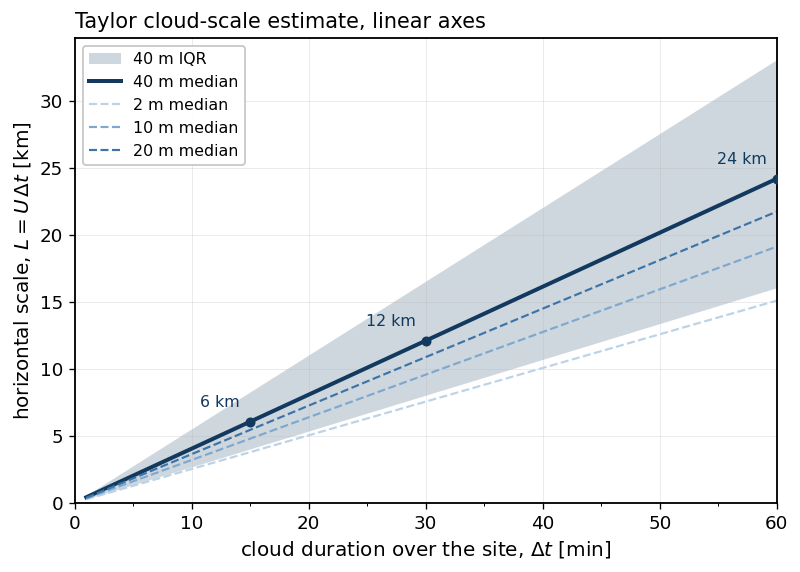

In [11]:
fig2, ax = plt.subplots(figsize=(6.8, 4.9))

dt_lin_min = np.linspace(1, 60, 200)
dt_lin_s = dt_lin_min * 60.0

ax.fill_between(
    dt_lin_min,
    taylor_length_km(U_Q25_M_S, dt_lin_s),
    taylor_length_km(U_Q75_M_S, dt_lin_s),
    color=LEVEL_COLORS_M[40.0], alpha=0.20, lw=0, label="40 m IQR",
)
ax.plot(dt_lin_min, taylor_length_km(U_MEDIAN_M_S, dt_lin_s),
        color=LEVEL_COLORS_M[40.0], lw=2.4, label="40 m median")
for h_m in (2.0, 10.0, 20.0):
    u_med_m_s = float(np.median(level_speeds_m_s(twr, h_m)))
    ax.plot(dt_lin_min, taylor_length_km(u_med_m_s, dt_lin_s),
            color=LEVEL_COLORS_M[h_m], lw=1.3, ls="--", label=f"{h_m:.0f} m median")

for dt_mark_min in (15.0, 30.0, 60.0):
    l_km = float(taylor_length_km(U_MEDIAN_M_S, dt_mark_min * 60.0))
    ax.plot([dt_mark_min], [l_km], "o", ms=5, color=LEVEL_COLORS_M[40.0], zorder=5)
    ax.annotate(f"{l_km:.0f} km", xy=(dt_mark_min, l_km),
                xytext=(-6, 9), textcoords="offset points",
                fontsize=9.5, ha="right", color=LEVEL_COLORS_M[40.0])

ax.set_xlim(0, 60)
ax.set_ylim(bottom=0)
ax.set_xlabel("cloud duration over the site, $\\Delta t$ [min]")
ax.set_ylabel("horizontal scale, $L = U\\,\\Delta t$ [km]")
ax.set_title("Taylor cloud-scale estimate, linear axes", loc="left")
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(5))
ax.legend(fontsize=9.5, loc="upper left")
ax.grid(alpha=0.25, lw=0.6)

fig2.tight_layout()
out_path2 = FIG_DIR / f"taylor_cloud_scale_linear_nsa_{SEASON_START}_{SEASON_END}.png"
fig2.savefig(out_path2)
print(f"figure saved: {out_path2}")
plt.show()

figure saved: figures/horizontal_cloud_scale_nsa_2025-10-01_2026-03-31.png


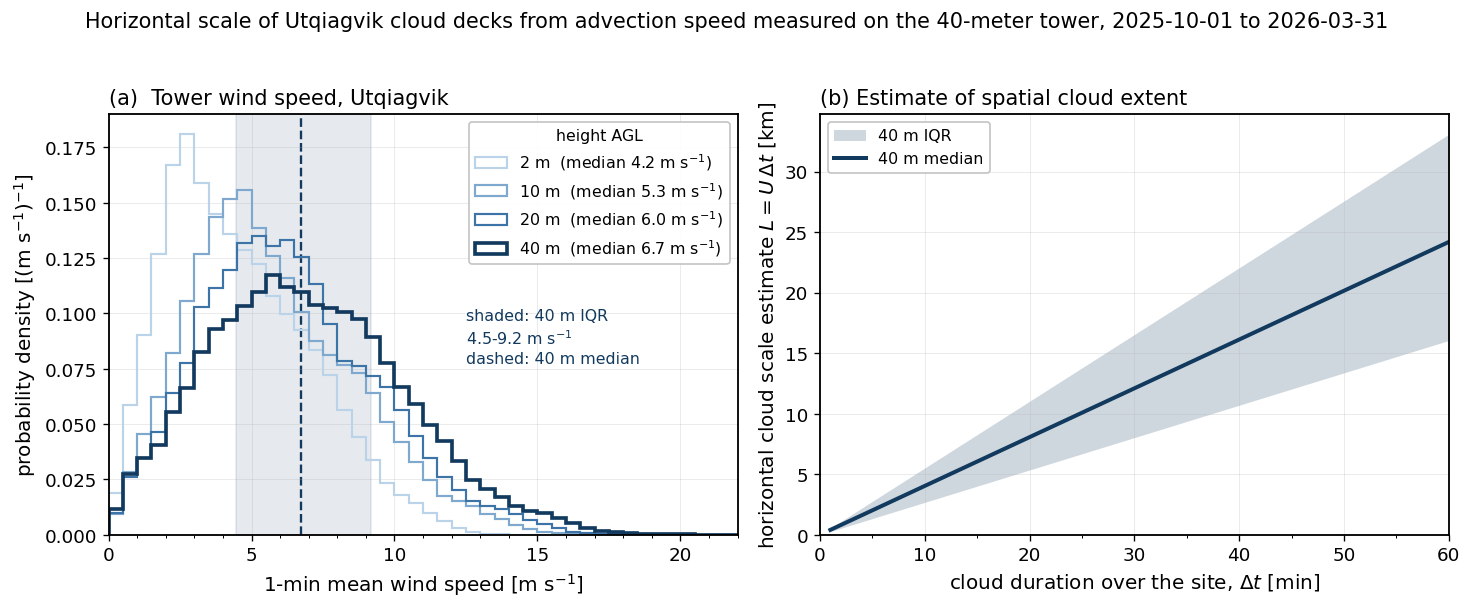

In [18]:
fig3, (ax_dist, ax_scale) = plt.subplots(1, 2, figsize=(12.4, 4.9))

# ---- (a) wind-speed distributions at all four tower levels ----------------
bins_m_s = np.arange(0, 26.5, 0.5)
for h_m in HEIGHTS_M:
    u_m_s = level_speeds_m_s(twr, h_m)
    ax_dist.hist(
        u_m_s,
        bins=bins_m_s,
        density=True,
        histtype="step",
        lw=2.2 if h_m == TOP_HEIGHT_M else 1.3,
        color=LEVEL_COLORS_M[h_m],
        label=f"{h_m:.0f} m  (median {np.median(u_m_s):.1f} m s$^{{-1}}$)",
    )

# Shade the 40-m IQR: this is the band that becomes the wedge in panel (b).
ax_dist.axvspan(U_Q25_M_S, U_Q75_M_S, color=LEVEL_COLORS_M[40.0], alpha=0.10, zorder=0)
ax_dist.axvline(U_MEDIAN_M_S, color=LEVEL_COLORS_M[40.0], ls="--", lw=1.4, zorder=1)
y_top = ax_dist.get_ylim()[1]
ax_dist.text(
    U_Q75_M_S + 3.3, y_top * 0.47,
    f"shaded: 40 m IQR\n{U_Q25_M_S:.1f}-{U_Q75_M_S:.1f} m s$^{{-1}}$\n"
    f"dashed: 40 m median",
    fontsize=9.5, color=LEVEL_COLORS_M[40.0], va="center", linespacing=1.35,
)

ax_dist.set_xlim(0, 22)
ax_dist.set_xlabel("1-min mean wind speed [m s$^{-1}$]")
ax_dist.set_ylabel("probability density [(m s$^{-1}$)$^{-1}$]")
ax_dist.set_title("(a)  Tower wind speed, Utqiagvik", loc="left")
ax_dist.xaxis.set_major_locator(MultipleLocator(5))
ax_dist.xaxis.set_minor_locator(MultipleLocator(1))
ax_dist.legend(title="height AGL", fontsize=9.5, title_fontsize=9.5, loc="upper right")
ax_dist.grid(alpha=0.25, lw=0.6)

# ---- (b) horizontal cloud scale estimate, linear axes ----------------
dt_lin_min = np.linspace(1, 60, 200)
dt_lin_s = dt_lin_min * 60.0

ax_scale.fill_between(
    dt_lin_min,
    taylor_length_km(U_Q25_M_S, dt_lin_s),
    taylor_length_km(U_Q75_M_S, dt_lin_s),
    color=LEVEL_COLORS_M[40.0], alpha=0.20, lw=0, label="40 m IQR",
)
ax_scale.plot(dt_lin_min, taylor_length_km(U_MEDIAN_M_S, dt_lin_s),
              color=LEVEL_COLORS_M[40.0], lw=2.4, label="40 m median")
# for h_m in (2.0, 10.0, 20.0):
#     u_med_m_s = float(np.median(level_speeds_m_s(twr, h_m)))
#     ax_scale.plot(dt_lin_min, taylor_length_km(u_med_m_s, dt_lin_s),
#                   color=LEVEL_COLORS_M[h_m], lw=1.3, ls="--", label=f"{h_m:.0f} m median")

# for dt_mark_min in (15.0, 30.0, 60.0):
#     l_km = float(taylor_length_km(U_MEDIAN_M_S, dt_mark_min * 60.0))
#     ax_scale.plot([dt_mark_min], [l_km], "o", ms=5, color=LEVEL_COLORS_M[40.0], zorder=5)
#     ax_scale.annotate(f"{l_km:.0f} km", xy=(dt_mark_min, l_km),
#                        xytext=(-6, 9), textcoords="offset points",
#                        fontsize=9.5, ha="right", color=LEVEL_COLORS_M[40.0])

ax_scale.set_xlim(0, 60)
ax_scale.set_ylim(bottom=0)
ax_scale.set_xlabel("cloud duration over the site, $\\Delta t$ [min]")
ax_scale.set_ylabel("horizontal cloud scale estimate $L = U\\,\\Delta t$ [km]")
ax_scale.set_title("(b) Estimate of spatial cloud extent", loc="left")
ax_scale.xaxis.set_major_locator(MultipleLocator(10))
ax_scale.xaxis.set_minor_locator(MultipleLocator(5))
ax_scale.legend(fontsize=9.5, loc="upper left")
ax_scale.grid(alpha=0.25, lw=0.6)

fig3.suptitle(
    f"Horizontal scale of Utqiagvik cloud decks from advection speed measured on the 40-meter tower, "
    f"{SEASON_START} to {SEASON_END}",
    y=1.03, fontsize=12.5,
)
fig3.tight_layout()
out_path = FIG_DIR / f"horizontal_cloud_scale_nsa_{SEASON_START}_{SEASON_END}.png"
fig3.savefig(out_path, dpi=350)
print(f"figure saved: {out_path}")
plt.show()

## 5. What the numbers say

In [13]:
def frac_below(u_m_s, threshold_m_s):
    return 100.0 * (u_m_s < threshold_m_s).mean()


print(f"Cold season {SEASON_START} .. {SEASON_END}, NSA C1 40-m tower")
print()
print(f"  U median = {U_MEDIAN_M_S:.2f} m/s, IQR {U_Q25_M_S:.2f}-{U_Q75_M_S:.2f} m/s "
      f"(n = {u_top_m_s.size:,} 1-min samples)")
print(f"  calm (U < 2 m/s): {frac_below(u_top_m_s, 2.0):.1f}% of the time; "
      f"U > 10 m/s: {100 - frac_below(u_top_m_s, 10.0):.1f}% of the time")
print()

for dt_min in (1.0, 10.0, 30.0, 60.0):
    lo_km = float(taylor_length_km(U_Q25_M_S, dt_min * 60.0))
    mid_km = float(taylor_length_km(U_MEDIAN_M_S, dt_min * 60.0))
    hi_km = float(taylor_length_km(U_Q75_M_S, dt_min * 60.0))
    print(f"  dt = {dt_min:4.0f} min  ->  L = {mid_km:6.2f} km"
          f"   (IQR {lo_km:5.2f} - {hi_km:5.2f} km)")

print()
print("Reminders: L is a CHORD through the deck, so it underestimates the")
print("cloud's largest horizontal dimension; the scalar wind speed pushes the")
print("other way; and the frozen-turbulence assumption weakens beyond roughly")
print("15-20 min, where individual stratocumulus cells turn over. Read the")
print("long-duration end as the scale of the deck, not of a single cell.")

Cold season 2025-10-01 .. 2026-03-31, NSA C1 40-m tower

  U median = 6.72 m/s, IQR 4.46-9.19 m/s (n = 261,582 1-min samples)
  calm (U < 2 m/s): 5.7% of the time; U > 10 m/s: 18.4% of the time

  dt =    1 min  ->  L =   0.40 km   (IQR  0.27 -  0.55 km)
  dt =   10 min  ->  L =   4.03 km   (IQR  2.67 -  5.51 km)
  dt =   30 min  ->  L =  12.09 km   (IQR  8.02 - 16.54 km)
  dt =   60 min  ->  L =  24.19 km   (IQR 16.05 - 33.08 km)

Reminders: L is a CHORD through the deck, so it underestimates the
cloud's largest horizontal dimension; the scalar wind speed pushes the
other way; and the frozen-turbulence assumption weakens beyond roughly
15-20 min, where individual stratocumulus cells turn over. Read the
long-duration end as the scale of the deck, not of a single cell.


### Next steps

The wind side of the conversion is now in place. To turn it into an actual
cloud-scale distribution rather than a nomogram, the missing ingredient is the
*observed* distribution of cloud durations $\Delta t$ over the site, which can
be built from a zenith cloud mask -- the ceilometer (`nsaceilC1.b1`), the
Doppler-lidar cloud-base height in `nsadlprofwstats4newsC1.c1`, or the
`thermocldphase` VAP already wired into this repo. Pairing each cloud episode
with the *concurrent* 40-m wind, rather than with the seasonal median used
here, would also remove the main source of spread in the IQR band above: within
an episode $U$ is known, and only the frozen-turbulence assumption itself
remains uncertain.

A better advection speed is available too. `nsadlprofwind4newsC1.c1` (Doppler
lidar wind profiles, ~100 m to 4.6 km, 15-min resolution) gives the wind at
actual cloud level instead of at the top of a 40-m tower. The tower is used
here because it is continuous, 1-min, and essentially always available; the
lidar profile is the upgrade once the cloud-base heights are in hand.